### Sanity check v2
- With updated dataset we will again do a limited-scope model using just two hard features (bullet mass and amount of propellant) to verify the physics are correctly working before expanding the amount of features

In [4]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("data/baseline_data_updated.csv")
df.head(20)

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,charge_weight,velocity_fps,barrel_length,data_source,primer,twist_rate,coal,compressed_load,jump_to_lands,amb_temp,pressure,case_capacity,suppressed
0,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n130,21.1,3402,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
1,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n133,22.8,3481,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
2,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n135,24.7,3514,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
3,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n140,26.2,3425,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
4,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n540,25.8,3301,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
5,223_rem,0.225,barnes,varmint_grenade,50.0,vihtavuori_n130,19.1,2877,25.0,vihtavuori,small_rifle_generic,12.0,2.201,NaN,NaN,NaN,NaN,NaN,NaN
6,223_rem,0.225,barnes,varmint_grenade,50.0,vihtavuori_n133,20.8,2959,25.0,vihtavuori,small_rifle_generic,12.0,2.201,NaN,NaN,NaN,NaN,NaN,NaN
7,223_rem,0.225,barnes,varmint_grenade,50.0,vihtavuori_n135,21.9,2976,25.0,vihtavuori,small_rifle_generic,12.0,2.201,NaN,NaN,NaN,NaN,NaN,NaN
8,223_rem,0.225,barnes,varmint_grenade,50.0,vihtavuori_n140,23.5,2963,25.0,vihtavuori,small_rifle_generic,12.0,2.201,NaN,NaN,NaN,NaN,NaN,NaN
9,223_rem,0.225,barnes,varmint_grenade,50.0,vihtavuori_n540,23.6,2920,25.0,vihtavuori,small_rifle_generic,12.0,2.201,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
three_oh_eight = df[df["cartridge"].isin(["308_win"])].copy()
len(three_oh_eight)

1254

In [9]:
three_oh_eight.head(20)

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,charge_weight,velocity_fps,barrel_length,data_source,primer,twist_rate,coal,compressed_load,jump_to_lands,amb_temp,pressure,case_capacity,suppressed
945,308_win,0.308,lapua,als,57.0,vihtavuori_n110,27.5,3481,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN
946,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n120,33.6,2890,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN
947,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n130,37.8,2986,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN
948,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n133,41.7,3097,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN
949,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n135,43.2,3123,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN
950,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n540,47.4,3114,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN
951,308_win,0.308,lapua,hpce_otce,100.0,vihtavuori_n110,20.4,2333,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN
952,308_win,0.308,lapua,hpce_otce,100.0,vihtavuori_n120,30.6,2663,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN
953,308_win,0.308,lapua,hpce_otce,100.0,vihtavuori_n130,33.7,2794,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN
954,308_win,0.308,lapua,hpce_otce,100.0,vihtavuori_n133,40.6,3012,24.0,vihtavuori,large_rifle_generic,12.0,2.638,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
features = ["charge_weight", "bullet_weight"]
target = ["velocity_fps"]
X = three_oh_eight[features].astype(float)
y = three_oh_eight[target].astype(float)

In [11]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
coeffs = pd.Series(model.coef_.ravel(), index=features)
intercept = model.intercept_
coeffs, intercept

(charge_weight    30.646965
 bullet_weight    -7.501866
 dtype: float64,
 array([2506.86816771]))

### As in previous baseline_zero, our sanity check appears to have passed.
- Increasing charge weight increases velocity
- Increasing bullet weight decreases velocity

In [14]:
from sklearn.metrics import mean_absolute_error

In [17]:
mean_pred = np.full_like(y, y.mean())
mae_zero = mean_absolute_error(y, mean_pred)  # floor mae

preds = model.predict(X)
mae_one = mean_absolute_error(y, preds)  # mae based on model learning from our two features

mae_zero, mae_one

(191.9525982565519, 72.89076409368025)

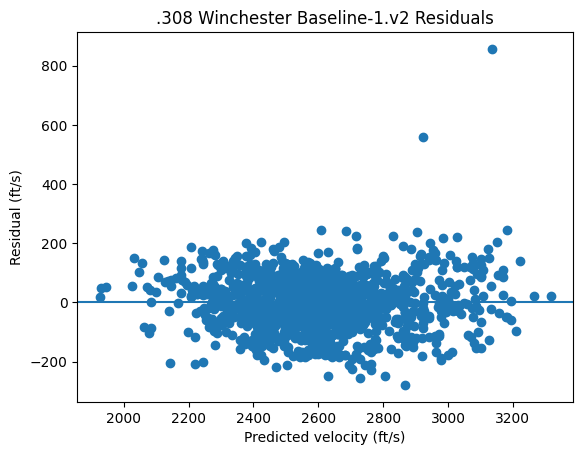

In [16]:
import matplotlib.pyplot as plt

residuals = y - preds

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title(".308 Winchester Baseline-1.v2 Residuals")
plt.show()

### Results are now becoming meaningful
- Regression model is showing a significantly lower mean error over the floor using only two features.
- Residual plot is behaving as desired: residuals are centered near zero so no gross bias, wide vertical spread due to lack of context/variables
- Wider residual spread at higher velocities line up with heteroscedasticity. Low to moderate velocities are easier for the model to predict more accurately, higher velocity combinations are more difficult to accurately model with limited features. *It will be interesting to see how the higher velocity residuals shift as things like barrel length and powder burn rates are introduced to the model.*